# Credit Scoring with XGBoost and SHAP on the German Credit Dataset

In credit scoring we care about two things:

1. **Predictive performance** – can we separate good and bad borrowers?
2. **Interpretability** – can we explain *why* the model approved or rejected someone?

This notebook walks through a complete, end‑to‑end example using the classic **UCI German Credit** dataset. We will:

- Build baseline models (logistic regression and XGBoost) to predict **good vs bad credit risk**.
- Tune and rebalance an XGBoost model for this imbalanced dataset.
- Choose a decision threshold using **business-style costs** for false positives vs false negatives.
- Calibrate the model’s probabilities so that 30% risk really looks like “about 30% of similar borrowers default”.
- Use **SHAP** to:
  - Understand which features matter globally.
  - Explain individual borrowers’ scores.
  - Run “what‑if” sensitivity analysis for key features.

Think of this notebook as the **storytelling / example notebook**. The reusable code lives in the
`credit_scoring_shap` package and the `SHAP_Credit.API.ipynb` notebook; here we show how to use that API in a realistic credit‑risk analysis.

---

## Roadmap

1. Load configuration and preprocess the German Credit data  
2. Train and interpret a **logistic‑regression baseline**  
3. Train a **baseline XGBoost** model  
4. Tune XGBoost hyperparameters with cross‑validation  
5. Handle class imbalance with `scale_pos_weight`  
6. Choose a decision threshold using **business costs**  
7. Calibrate probabilities and inspect a reliability curve  
8. Analyze **global** feature importance with SHAP  
9. Explain **individual borrowers** with SHAP decision plots  
10. Run **sensitivity analysis**: what happens if we change a borrower’s features?


In [1]:
# Cell 1: Imports, paths, config, data loading

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Image, display

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    brier_score_loss,
)
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

import xgboost as xgb
import shap

# Project imports (adjust paths if needed)
sys.path.append("/workspace")
sys.path.append("/workspace/credit_scoring_shap")

from credit_scoring_shap.config import TrainingConfig
from credit_scoring_shap.data import load_raw_data, load_and_preprocess
from credit_scoring_shap.modeling import build_model, train_model, evaluate_model
from credit_scoring_shap.evaluation import (
    plot_confusion_matrix,
    plot_roc_curves,
    save_metrics_text,
)
from credit_scoring_shap.explain import (
    build_shap_explainer,
    plot_global_shap_summary,
    plot_shap_dependence_for_top_feature,
    plot_shap_decision_for_index,
)
from credit_scoring_shap.sensitivity import run_sensitivity_for_instance

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
cfg = TrainingConfig()
reports_dir = cfg.ensure_reports_dir()

# Load raw data (for inspection only)
df_raw = load_raw_data(cfg.data)

# Load preprocessed / encoded data for modeling
X_train, X_test, y_train, y_test, preproc, feature_names = load_and_preprocess(
    cfg.data
)

print("Raw shape:", df_raw.shape)
print("Encoded X_train shape:", X_train.shape)
print("Encoded X_test shape:", X_test.shape)
print("Train positive rate:", y_train.mean())
print("Test positive rate :", y_test.mean())
print("First 10 features:", feature_names[:10])

Fetching German Credit Data from UCI ML Repository...
Fetching German Credit Data from UCI ML Repository...
Raw shape: (1000, 21)
Encoded X_train shape: (800, 61)
Encoded X_test shape: (200, 61)
Train positive rate: 0.7
Test positive rate : 0.7
First 10 features: ['duration_months', 'credit_amount', 'installment_rate', 'residence_since', 'age_years', 'existing_credits', 'num_dependents', 'status_checking_account_A11', 'status_checking_account_A12', 'status_checking_account_A13']


`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.


## Data configuration and preprocessing

In this section we wire up the **project configuration** and preprocessing pipeline.

### What’s happening here

- `TrainingConfig()` builds a configuration object that holds:
  - `data` settings: where to fetch the UCI German Credit CSV, the target column, the train/test split, etc.
  - `model` settings: default XGBoost hyperparameters.
  - a `reports_dir` where we will save all plots and metrics.

- `load_raw_data(cfg.data)` fetches the original German Credit data for inspection.

- `load_and_preprocess(cfg.data)` runs the full preprocessing pipeline:
  - splits into train/test,
  - encodes categorical variables (one‑hot) and scales numeric ones,
  - returns `X_train`, `X_test`, `y_train`, `y_test`,
  - also returns the fitted preprocessing object and a list of final `feature_names`.

### What to notice

From the printed output:

- **Raw shape:** `(1000, 21)` – 1,000 borrowers and 21 original columns.  
- **Encoded features:** `61` final predictors after one‑hot encoding.  
- **Train/Test positive rate:** both around **0.70**, meaning roughly 70% of observations are labeled *Good* and 30% *Bad*.

That 70/30 split is a mild **class imbalance**, which we will handle later with `scale_pos_weight` and cost‑sensitive threshold tuning.

The first few feature names confirm that we have the expected credit‑risk variables: duration in months, credit amount, installment rate, residence time, age, account status dummies, and so on.


## Logistic‑regression baseline

Before using tree ensembles, we start with a **logistic‑regression baseline**.

This is the traditional workhorse model for credit scoring:

- It is simple and well understood.
- Coefficients can be mapped to odds ratios.
- It sets a strong baseline for more complex models.

### What this step does

- Fits `LogisticRegression(max_iter=1000, solver="liblinear")` on `X_train` and `y_train`.
- Predicts probabilities `y_proba_lr` on `X_test`.
- Converts probabilities to hard labels at threshold **0.5** to get `y_pred_lr`.
- Computes:
  - **AUC** (`roc_auc_score`),
  - **confusion matrix**,
  - **classification report** (precision, recall, F1 for both classes).

We also save metrics into a dictionary for later reporting.


In [3]:
# Cell 2: Logistic regression baseline – training & evaluation

log_reg = LogisticRegression(
    max_iter=1000,
    solver="liblinear",
)

log_reg.fit(X_train, y_train)

y_proba_lr = log_reg.predict_proba(X_test)[:, 1]
y_pred_lr = (y_proba_lr >= 0.5).astype(int)

auc_lr = roc_auc_score(y_test, y_proba_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)
report_lr = classification_report(y_test, y_pred_lr, target_names=["Bad", "Good"])

metrics_lr = {
    "auc": float(auc_lr),
    "confusion_matrix": cm_lr,
    "classification_report": report_lr,
    "threshold": 0.5,
}

print("Logistic Regression – AUC:", metrics_lr["auc"])
print("Confusion matrix:\n", metrics_lr["confusion_matrix"])
print("\nClassification report:\n", metrics_lr["classification_report"])


Logistic Regression – AUC: 0.7596428571428571
Confusion matrix:
 [[ 27  33]
 [ 25 115]]

Classification report:
               precision    recall  f1-score   support

         Bad       0.52      0.45      0.48        60
        Good       0.78      0.82      0.80       140

    accuracy                           0.71       200
   macro avg       0.65      0.64      0.64       200
weighted avg       0.70      0.71      0.70       200



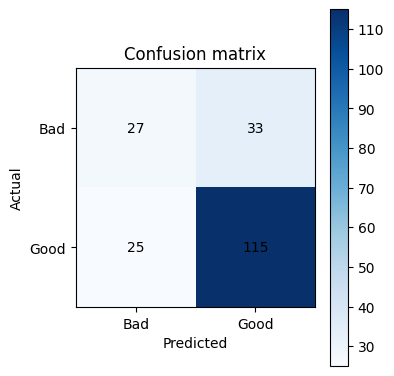

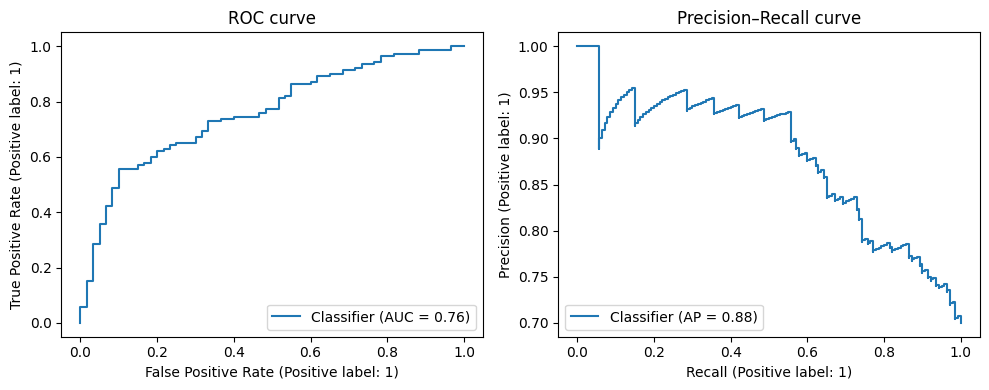

In [4]:
# Cell 3: Logistic regression – plots & metrics file

plot_confusion_matrix(
    metrics_lr["confusion_matrix"],
    cfg,
    class_names=("Bad", "Good"),
    filename="confusion_matrix_logreg.png",
)

plot_roc_curves(
    y_test,
    y_proba_lr,
    cfg,
    filename="roc_pr_curves_logreg.png",
)

save_metrics_text(
    metrics_lr,
    cfg,
    filename="metrics_logreg.txt",
)

for fname in ["confusion_matrix_logreg.png", "roc_pr_curves_logreg.png"]:
    path = os.path.join(cfg.reports_dir, fname)
    if os.path.exists(path):
        display(Image(filename=path, width=600))
    else:
        print("Missing:", path)


### Interpreting the logistic‑regression results

The confusion matrix for logistic regression looks like this:

- True **Bad** (0):  
  - 27 correctly predicted as Bad (top‑left),  
  - 33 incorrectly predicted as Good (top‑right).
- True **Good** (1):  
  - 115 correctly predicted as Good (bottom‑right),  
  - 25 incorrectly predicted as Bad (bottom‑left).

So at threshold 0.5, the model:

- **Catches 27 / 60 ≈ 45%** of the bad borrowers,
- **Approves 115 / 140 ≈ 82%** of the good borrowers.

From the ROC and Precision–Recall curves:

- **ROC AUC ≈ 0.76**, meaning the model ranks good vs bad borrowers fairly well.  
- **Average Precision (AP) ≈ 0.88** on the PR curve, which is strong given the 70/30 class mix.

This baseline is already realistic: a lender could use it, but there is still room to:

- Improve ranking slightly,
- Adjust the trade‑off between catching bad borrowers and not rejecting too many good ones.


## Baseline XGBoost model

Next we move to **XGBoost**, a gradient‑boosted tree ensemble that usually performs very well on tabular data.

Here we build a **baseline XGBoost model with default hyperparameters** from `cfg.model`, without any tuning yet.

### What this step does

- Calls `build_model(cfg.model)` to construct an `xgb.XGBClassifier`.
- Trains the model on `X_train, y_train` using `train_model`.
- Evaluates on the test set via `evaluate_model`:
  - predicted probabilities,
  - hard predictions at threshold 0.5,
  - AUC, confusion matrix, classification report.
- Plots confusion matrix and ROC/PR curves, and saves them to `reports/`.


In [5]:
# Cell 4: Baseline XGBoost model – training & evaluation (no tuning yet)

xgb_model = build_model(cfg.model)
xgb_model = train_model(xgb_model, X_train, y_train)

metrics_xgb, y_proba_xgb, y_pred_xgb = evaluate_model(
    xgb_model,
    X_test,
    y_test,
    threshold=0.5,
)

print("Baseline XGBoost – AUC:", metrics_xgb["auc"])
print("Confusion matrix:\n", metrics_xgb["confusion_matrix"])
print("\nClassification report:\n", metrics_xgb["classification_report"])


[13:39:48] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.



Baseline XGBoost – AUC: 0.7553571428571428
Confusion matrix:
 [[ 27  33]
 [ 23 117]]

Classification report:
               precision    recall  f1-score   support

         Bad       0.54      0.45      0.49        60
        Good       0.78      0.84      0.81       140

    accuracy                           0.72       200
   macro avg       0.66      0.64      0.65       200
weighted avg       0.71      0.72      0.71       200



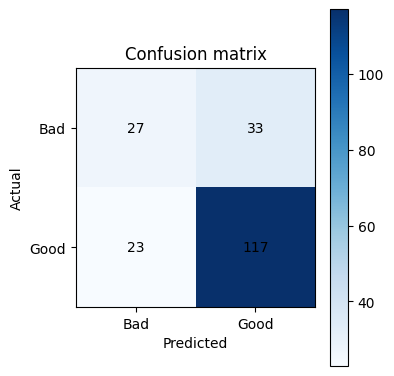

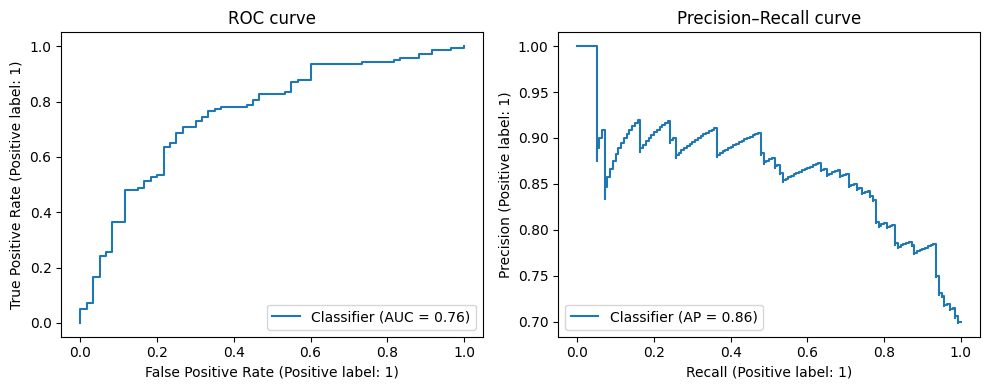

In [6]:
# Cell 5: Baseline XGBoost – plots & metrics file

plot_confusion_matrix(
    metrics_xgb["confusion_matrix"],
    cfg,
    class_names=("Bad", "Good"),
    filename="confusion_matrix_xgb_baseline.png",
)

plot_roc_curves(
    y_test,
    y_proba_xgb,
    cfg,
    filename="roc_pr_curves_xgb_baseline.png",
)

save_metrics_text(
    metrics_xgb,
    cfg,
    filename="metrics_xgb_baseline.txt",
)

for fname in ["confusion_matrix_xgb_baseline.png", "roc_pr_curves_xgb_baseline.png"]:
    path = os.path.join(cfg.reports_dir, fname)
    if os.path.exists(path):
        display(Image(filename=path, width=600))
    else:
        print("Missing:", path)

### Baseline XGBoost vs logistic regression

For the **untuned** XGBoost model, the confusion matrix on the test set is:

- True **Bad**: 27 correctly predicted as Bad, 33 predicted as Good.  
- True **Good**: 117 correctly predicted as Good, 23 predicted as Bad.

So compared to logistic regression:

- The number of false negatives (bad borrowers predicted as good) is the same (33).
- False positives (good predicted as bad) drop slightly from 25 → 23.
- Overall accuracy and class metrics are very similar.

The curves show:

- **ROC AUC ≈ 0.76**, almost identical to the logistic baseline.  
- **Average Precision (AP) ≈ 0.86**, slightly lower than the logistic model.

Key lesson: **just switching to a more powerful model is not enough**.  
To unlock XGBoost’s strength we need to tune hyperparameters and explicitly handle the class imbalance.


## Hyperparameter tuning with cross‑validation

Now we perform **grid‑search hyperparameter tuning** to improve XGBoost.

### Search setup

- We use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` for stable cross‑validation.
- The parameter grid explores:

  - `max_depth`: {3, 4, 5}  
  - `learning_rate`: {0.01, 0.05, 0.10}  
  - `n_estimators`: {200, 400}  
  - `subsample`: {0.8, 1.0}  
  - `colsample_bytree`: {0.8, 1.0}

- That’s **72 candidates** × 5 folds = 360 fits.
- We score models by **ROC AUC**.

`GridSearchCV` then finds the set of hyperparameters with the best mean CV AUC.


In [7]:
# Cell 6: Cross-validation + hyperparameter tuning for XGBoost (GridSearchCV)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_tune = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

param_grid = {
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [200, 400],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

grid_cv = GridSearchCV(
    estimator=xgb_tune,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid_cv.fit(X_train, y_train)


Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importanc...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=-1, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5], 'n_estimators': [200, 400],
                         'subsample': [0.8, 1.0]},
             scoring='roc_auc', verbose=1)

In [8]:
# Cell 7: Best tuned model – CV results

print("Best CV AUC:", grid_cv.best_score_)
print("Best parameters:")
grid_cv.best_params_


Best CV AUC: 0.7937127976190477
Best parameters:


{'colsample_bytree': 0.8,
 'learning_rate': 0.05,
 'max_depth': 3,
 'n_estimators': 200,
 'subsample': 0.8}

In [9]:
# Cell 8: Evaluate tuned XGBoost on the held-out test set

best_xgb = grid_cv.best_estimator_

y_proba_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb_tuned = (y_proba_xgb_tuned >= 0.5).astype(int)

auc_xgb_tuned = roc_auc_score(y_test, y_proba_xgb_tuned)
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)
report_xgb_tuned = classification_report(
    y_test,
    y_pred_xgb_tuned,
    target_names=["Bad", "Good"],
)

metrics_xgb_tuned = {
    "auc": float(auc_xgb_tuned),
    "confusion_matrix": cm_xgb_tuned,
    "classification_report": report_xgb_tuned,
    "threshold": 0.5,
}

print("Tuned XGBoost – Test AUC:", metrics_xgb_tuned["auc"])
print("Confusion matrix:\n", metrics_xgb_tuned["confusion_matrix"])
print("\nClassification report:\n", metrics_xgb_tuned["classification_report"])

Tuned XGBoost – Test AUC: 0.761547619047619
Confusion matrix:
 [[ 28  32]
 [ 19 121]]

Classification report:
               precision    recall  f1-score   support

         Bad       0.60      0.47      0.52        60
        Good       0.79      0.86      0.83       140

    accuracy                           0.74       200
   macro avg       0.69      0.67      0.67       200
weighted avg       0.73      0.74      0.74       200



In [10]:
# Cell 14: Handle class imbalance and refit tuned XGBoost with scale_pos_weight

# Compute class imbalance on the training set
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"Train counts -> negative: {neg_count}, positive: {pos_count}")
print(f"scale_pos_weight to use for XGBoost: {scale_pos_weight:.3f}")

# Build a new tuned model using the best params from GridSearchCV + scale_pos_weight
best_params = grid_cv.best_params_.copy()
best_params.update(
    dict(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
        scale_pos_weight=scale_pos_weight,
    )
)

best_xgb_balanced = xgb.XGBClassifier(**best_params)
best_xgb_balanced.fit(X_train, y_train)

# Evaluate at default threshold 0.5
y_proba_xgb_bal = best_xgb_balanced.predict_proba(X_test)[:, 1]
y_pred_xgb_bal_05 = (y_proba_xgb_bal >= 0.5).astype(int)

auc_xgb_bal_05 = roc_auc_score(y_test, y_proba_xgb_bal)
cm_xgb_bal_05 = confusion_matrix(y_test, y_pred_xgb_bal_05)
report_xgb_bal_05 = classification_report(
    y_test, y_pred_xgb_bal_05, target_names=["Bad", "Good"]
)

metrics_xgb_bal_05 = {
    "auc": float(auc_xgb_bal_05),
    "confusion_matrix": cm_xgb_bal_05,
    "classification_report": report_xgb_bal_05,
    "threshold": 0.5,
}

print("Balanced tuned XGBoost (threshold=0.5) – Test AUC:", metrics_xgb_bal_05["auc"])
print("Confusion matrix:\n", metrics_xgb_bal_05["confusion_matrix"])
print("\nClassification report:\n", metrics_xgb_bal_05["classification_report"])

Train counts -> negative: 240, positive: 560
scale_pos_weight to use for XGBoost: 0.429
Balanced tuned XGBoost (threshold=0.5) – Test AUC: 0.7595238095238095
Confusion matrix:
 [[43 17]
 [46 94]]

Classification report:
               precision    recall  f1-score   support

         Bad       0.48      0.72      0.58        60
        Good       0.85      0.67      0.75       140

    accuracy                           0.69       200
   macro avg       0.66      0.69      0.66       200
weighted avg       0.74      0.69      0.70       200



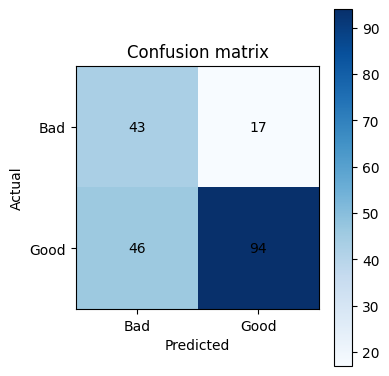

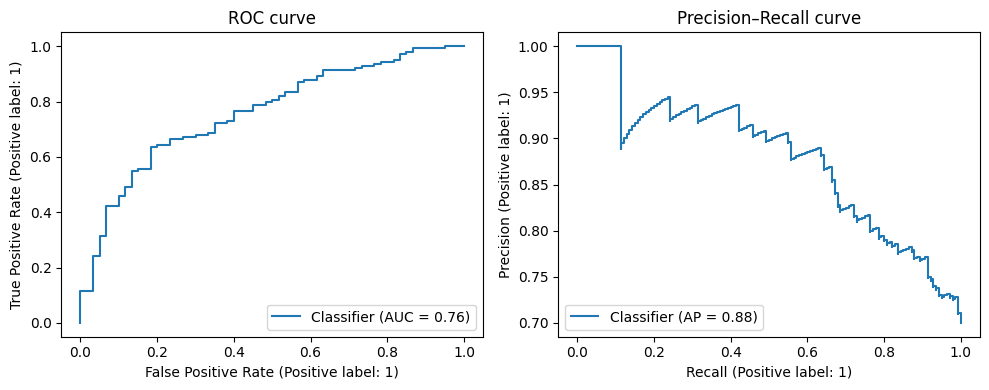

In [11]:
# Cell 15: Balanced tuned XGBoost – plots & metrics file

plot_confusion_matrix(
    metrics_xgb_bal_05["confusion_matrix"],
    cfg,
    class_names=("Bad", "Good"),
    filename="confusion_matrix_xgb_tuned_balanced_05.png",
)

plot_roc_curves(
    y_test,
    y_proba_xgb_bal,
    cfg,
    filename="roc_pr_curves_xgb_tuned_balanced_05.png",
)

save_metrics_text(
    metrics_xgb_bal_05,
    cfg,
    filename="metrics_xgb_tuned_balanced_05.txt",
)

for fname in [
    "confusion_matrix_xgb_tuned_balanced_05.png",
    "roc_pr_curves_xgb_tuned_balanced_05.png",
]:
    path = os.path.join(cfg.reports_dir, fname)
    if os.path.exists(path):
        display(Image(filename=path))
    else:
        print("Missing:", path)


In [12]:
# Cell 16: Threshold tuning with business costs

def threshold_sweep_with_cost(
    y_true,
    y_proba,
    thresholds,
    fn_cost=5.0,
    fp_cost=1.0,
):
    """
    Sweep decision thresholds for a binary classifier and compute a simple cost-based objective.

    Parameters
    ----------
    y_true : array-like
        True binary labels (0/1).
    y_proba : array-like
        Predicted probabilities for the positive class.
    thresholds : iterable of float
        Thresholds to evaluate.
    fn_cost : float
        Cost of a false negative (bad borrower approved).
    fp_cost : float
        Cost of a false positive (good borrower rejected).

    Returns
    -------
    pd.DataFrame
        One row per threshold with confusion-matrix counts and total cost.
    """
    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        total_cost = fn * fn_cost + fp * fp_cost
        rows.append(
            {
                "threshold": t,
                "tn": tn,
                "fp": fp,
                "fn": fn,
                "tp": tp,
                "total_cost": total_cost,
            }
        )
    return pd.DataFrame(rows)


thresholds = np.linspace(0.1, 0.9, 17)
sweep_df = threshold_sweep_with_cost(
    y_true=y_test,
    y_proba=y_proba_xgb_bal,
    thresholds=thresholds,
    fn_cost=5.0,  # false negatives are much more costly
    fp_cost=1.0,
)

best_row = sweep_df.loc[sweep_df["total_cost"].idxmin()]
best_threshold = float(best_row["threshold"])

print("Best threshold by cost:", best_threshold)
print(best_row)

# Evaluate balanced model at the chosen threshold
y_pred_xgb_bal_best = (y_proba_xgb_bal >= best_threshold).astype(int)
auc_xgb_bal_best = roc_auc_score(y_test, y_proba_xgb_bal)
cm_xgb_bal_best = confusion_matrix(y_test, y_pred_xgb_bal_best)
report_xgb_bal_best = classification_report(
    y_test, y_pred_xgb_bal_best, target_names=["Bad", "Good"]
)

metrics_xgb_bal_best = {
    "auc": float(auc_xgb_bal_best),
    "confusion_matrix": cm_xgb_bal_best,
    "classification_report": report_xgb_bal_best,
    "threshold": best_threshold,
}

print("\nBalanced tuned XGBoost – Test AUC (best threshold):", metrics_xgb_bal_best["auc"])
print("Confusion matrix (best threshold):\n", metrics_xgb_bal_best["confusion_matrix"])
print("\nClassification report (best threshold):\n", metrics_xgb_bal_best["classification_report"])


Best threshold by cost: 0.1
threshold       0.1
tn              1.0
fp             59.0
fn              0.0
tp            140.0
total_cost     59.0
Name: 0, dtype: float64

Balanced tuned XGBoost – Test AUC (best threshold): 0.7595238095238095
Confusion matrix (best threshold):
 [[  1  59]
 [  0 140]]

Classification report (best threshold):
               precision    recall  f1-score   support

         Bad       1.00      0.02      0.03        60
        Good       0.70      1.00      0.83       140

    accuracy                           0.70       200
   macro avg       0.85      0.51      0.43       200
weighted avg       0.79      0.70      0.59       200



`base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.


Brier score (uncalibrated): 0.1986
Brier score (calibrated)  : 0.1772


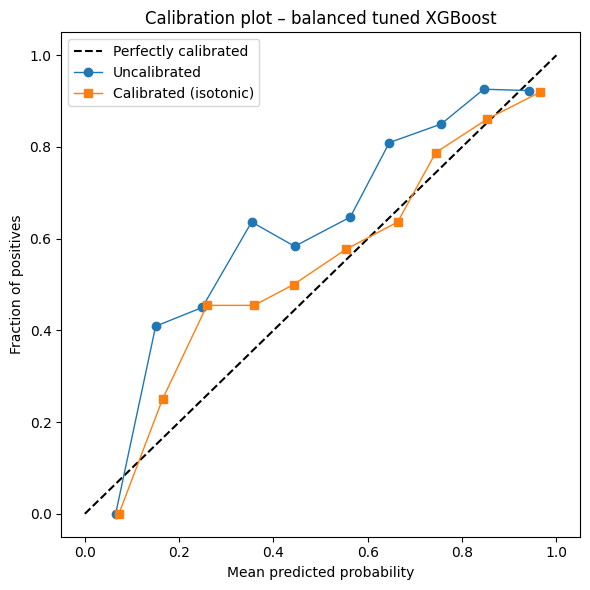

Calibration plot saved to: reports/calibration_xgb_tuned_balanced.png


In [13]:
# Cell 17: Calibrate probabilities for the balanced tuned model

# Wrap the tuned balanced model in a CalibratedClassifierCV
calibrated_clf = CalibratedClassifierCV(
    base_estimator=best_xgb_balanced,
    method="isotonic",
    cv=5,
)

calibrated_clf.fit(X_train, y_train)

# Uncalibrated vs calibrated probabilities on the test set
y_proba_uncal = y_proba_xgb_bal
y_proba_cal = calibrated_clf.predict_proba(X_test)[:, 1]

brier_uncal = brier_score_loss(y_test, y_proba_uncal)
brier_cal = brier_score_loss(y_test, y_proba_cal)

print(f"Brier score (uncalibrated): {brier_uncal:.4f}")
print(f"Brier score (calibrated)  : {brier_cal:.4f}")

# Reliability curves
prob_true_uncal, prob_pred_uncal = calibration_curve(
    y_test, y_proba_uncal, n_bins=10
)
prob_true_cal, prob_pred_cal = calibration_curve(
    y_test, y_proba_cal, n_bins=10
)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")

plt.plot(
    prob_pred_uncal,
    prob_true_uncal,
    marker="o",
    linewidth=1,
    label="Uncalibrated",
)
plt.plot(
    prob_pred_cal,
    prob_true_cal,
    marker="s",
    linewidth=1,
    label="Calibrated (isotonic)",
)
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration plot – balanced tuned XGBoost")
plt.legend(loc="best")
plt.tight_layout()

calibration_plot_path = os.path.join(cfg.reports_dir, "calibration_xgb_tuned_balanced.png")
plt.savefig(calibration_plot_path, bbox_inches="tight")
plt.show()

print("Calibration plot saved to:", calibration_plot_path)

Top SHAP feature (balanced model): status_checking_account_A14


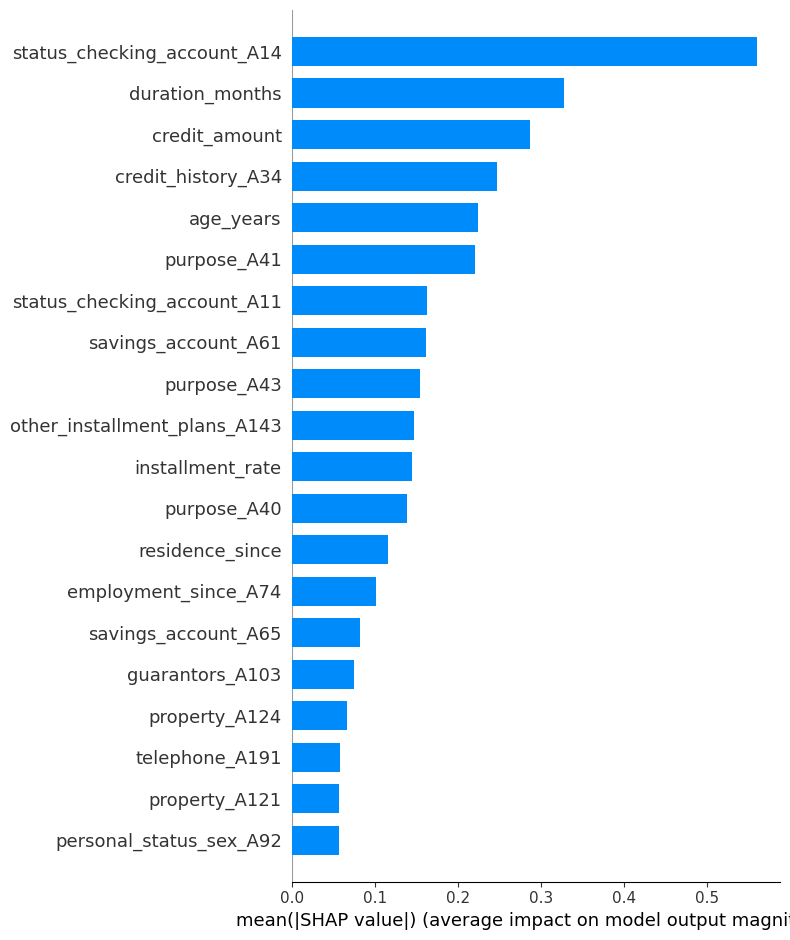

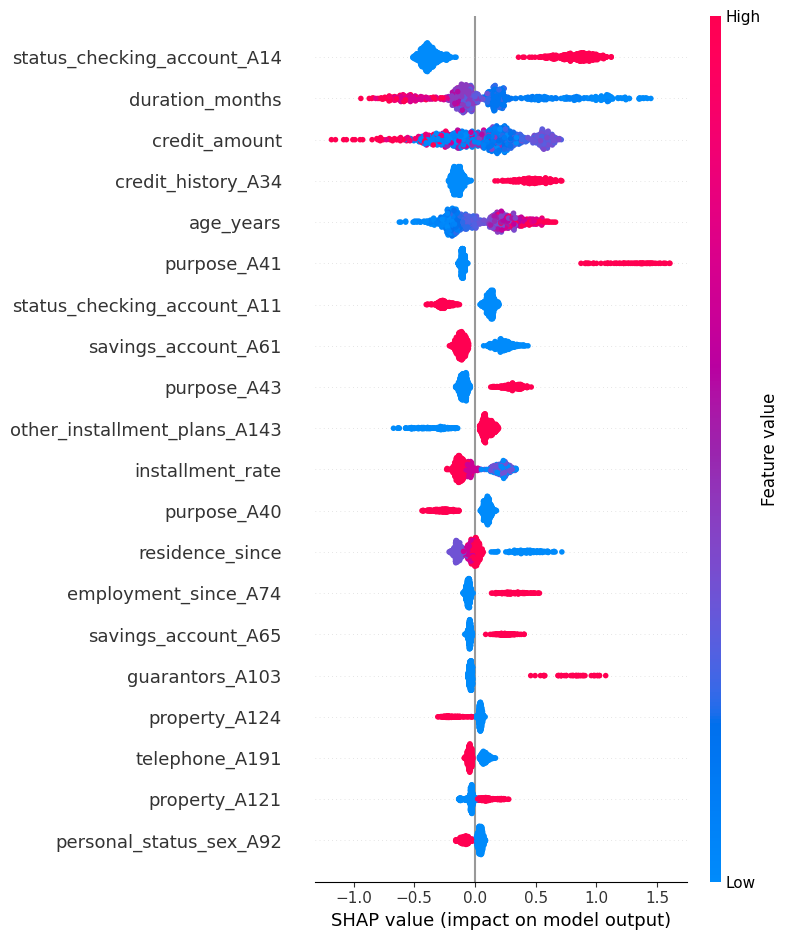

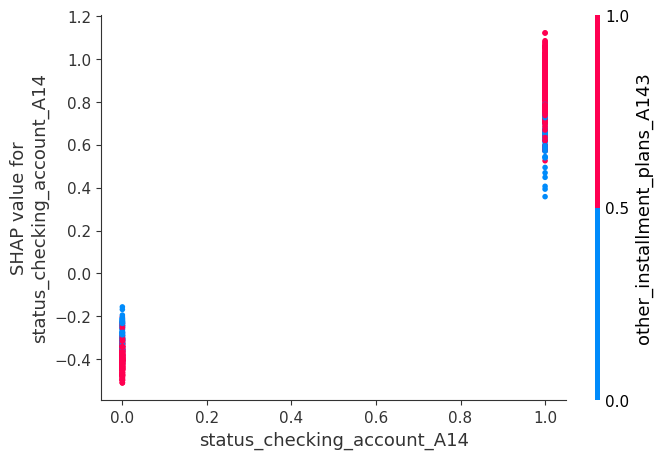

In [14]:
# Cell 18: SHAP global explanations for the balanced tuned XGBoost model

shap.initjs()

explainer_bal, shap_values_train_bal = build_shap_explainer(
    best_xgb_balanced,
    X_train,
)

# Handle list output case for binary classification
if isinstance(shap_values_train_bal, list):
    shap_values_train_bal = shap_values_train_bal[1]

plot_global_shap_summary(
    shap_values_train_bal,
    X_train,
    cfg,
)

top_feature_bal = plot_shap_dependence_for_top_feature(
    shap_values_train_bal,
    X_train,
    cfg,
)

print("Top SHAP feature (balanced model):", top_feature_bal)

for fname in [
    "shap_summary_bar.png",
    "shap_summary_beeswarm.png",
    f"shap_dependence_{top_feature_bal.replace(' ', '_')}.png",
]:
    path = os.path.join(cfg.reports_dir, fname)
    if os.path.exists(path):
        display(Image(filename=path, width=500))
    else:
        print("Missing:", path)

Good idx: 0 Bad idx: 4


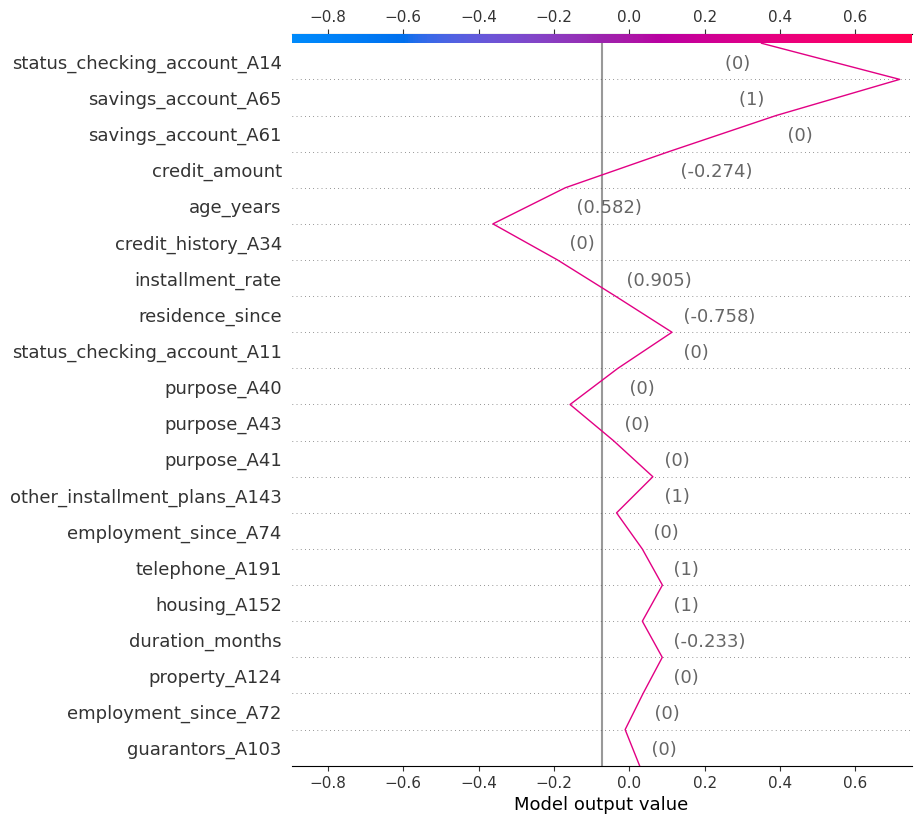

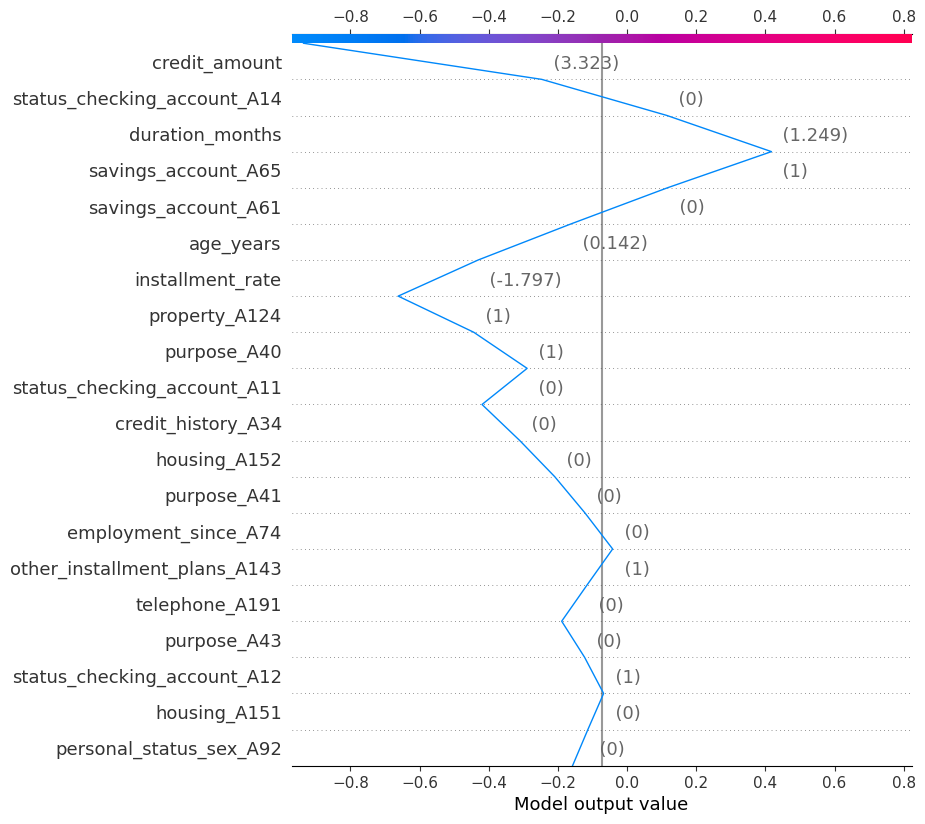

In [15]:
# Cell 15: Local SHAP decision plots for one good and one bad borrower (balanced model)

# We need SHAP values aligned to X_test for local explanations
shap_values_test_bal = explainer_bal.shap_values(X_test)
if isinstance(shap_values_test_bal, list):
    shap_values_test_bal = shap_values_test_bal[1]

good_idx = None
bad_idx = None

for i, y in enumerate(y_test.values):
    if y == 1 and good_idx is None:
        good_idx = i
    if y == 0 and bad_idx is None:
        bad_idx = i
    if good_idx is not None and bad_idx is not None:
        break

print("Good idx:", good_idx, "Bad idx:", bad_idx)

if good_idx is not None:
    plot_shap_decision_for_index(
        explainer_bal,
        shap_values_test_bal,
        X_test,
        good_idx,
        cfg,
        prefix="good_balanced",
    )

if bad_idx is not None:
    plot_shap_decision_for_index(
        explainer_bal,
        shap_values_test_bal,
        X_test,
        bad_idx,
        cfg,
        prefix="bad_balanced",
    )

for prefix, idx in [("good_balanced", good_idx), ("bad_balanced", bad_idx)]:
    if idx is None:
        continue
    fname = f"shap_decision_{prefix}_{idx}.png"
    path = os.path.join(cfg.reports_dir, fname)
    if os.path.exists(path):
        display(Image(filename=path, width=500))
    else:
        print("Missing:", path)


In [16]:
# Cell 16: Sensitivity analysis for top SHAP features (good and bad examples, balanced model)

sens_results = {}

if good_idx is not None:
    sens_results["good_balanced"] = run_sensitivity_for_instance(
        model=best_xgb_balanced,
        X=X_test,
        shap_values=shap_values_test_bal,
        cfg=cfg,
        instance_idx=good_idx,
        top_n=3,
    )

if bad_idx is not None:
    sens_results["bad_balanced"] = run_sensitivity_for_instance(
        model=best_xgb_balanced,
        X=X_test,
        shap_values=shap_values_test_bal,
        cfg=cfg,
        instance_idx=bad_idx,
        top_n=3,
    )

print("Sensitivity keys:", list(sens_results.keys()))
for k, v in sens_results.items():
    print(f"\nInstance type: {k}")
    for feat, pairs in v.items():
        print(f"  Feature: {feat}, #points: {len(pairs)}")


Sensitivity keys: ['good_balanced', 'bad_balanced']

Instance type: good_balanced
  Feature: status_checking_account_A14, #points: 20
  Feature: savings_account_A65, #points: 20
  Feature: savings_account_A61, #points: 20

Instance type: bad_balanced
  Feature: credit_amount, #points: 20
  Feature: status_checking_account_A14, #points: 20
  Feature: duration_months, #points: 20


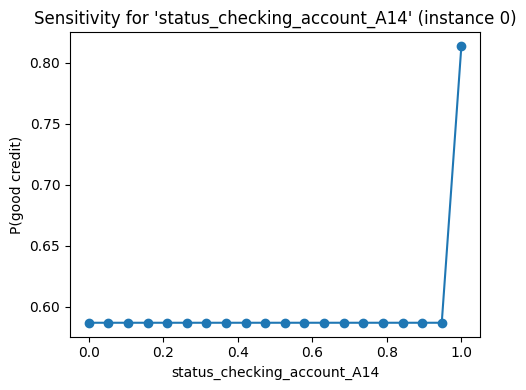

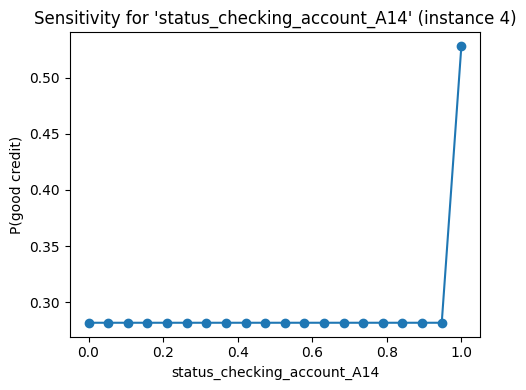

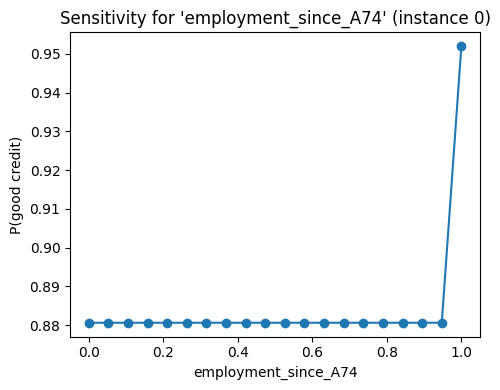

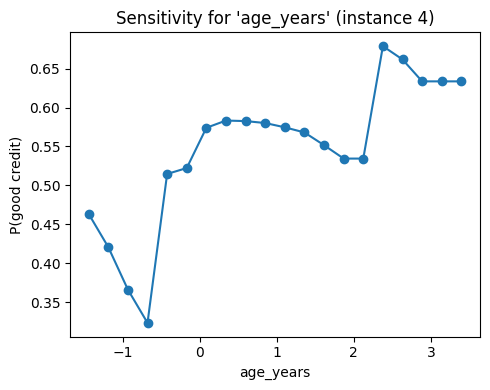

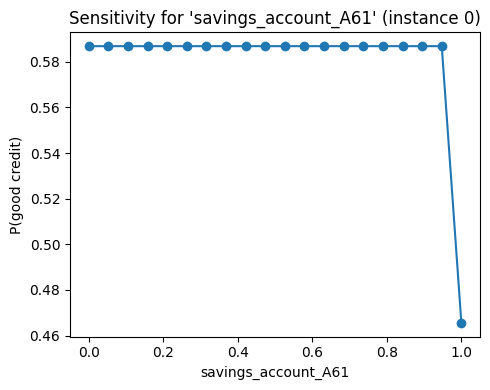

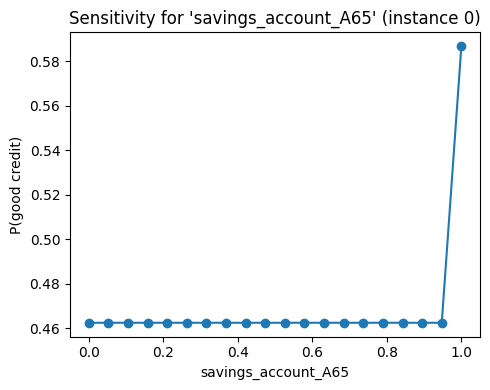

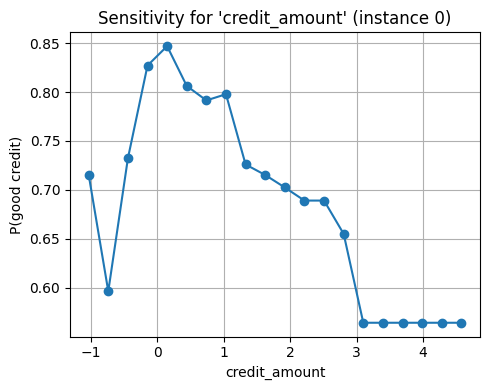

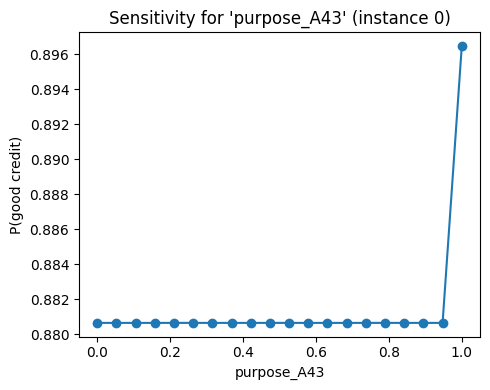

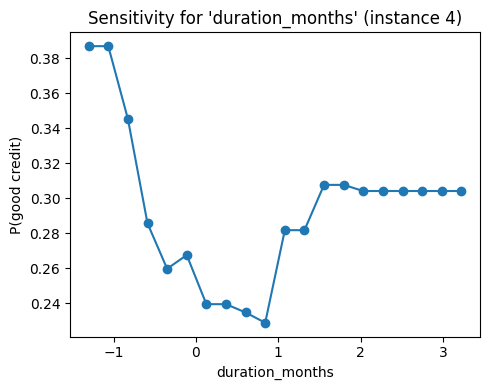

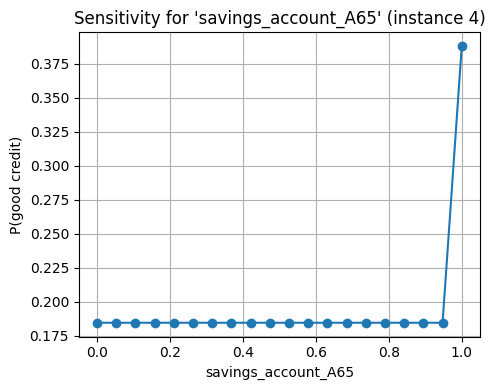

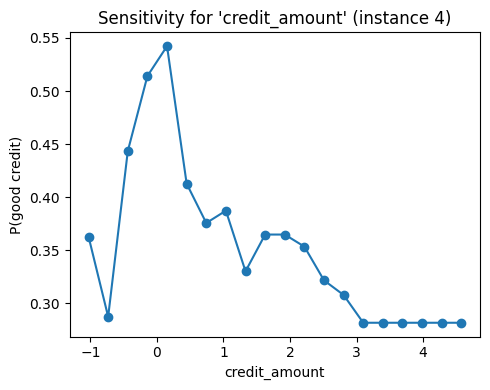

In [17]:
# Cell 17: Display saved sensitivity plots (balanced model)

sens_files = [
    f
    for f in os.listdir(cfg.reports_dir)
    if f.startswith("sensitivity_") and f.endswith(".png")
]

for fname in sens_files:
    path = os.path.join(cfg.reports_dir, fname)
    display(Image(filename=path, width=300))